# 02 · Predictive maintenance — FD001

This notebook grows block by block during Phase 1.
- **Block 1.2** (sections 1–5): features and leakage-safe validation.
- **Block 1.3** (sections 6–11): model comparison, decision threshold and test evaluation.

Decisions taken from notebook 01 (details in `docs/ml.md`):
- 14 sensors kept; the 6 constant sensors, the near-constant sensor 6 and the 3 operational settings are discarded.
- Sensor noise is large compared with the degradation trend until roughly the last 50–100 cycles, so the level of each sensor is smoothed.
- Units start at different levels, so each unit is compared with its own early-life baseline.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score

from industrial_ai.ml.data import SENSOR_DESCRIPTIONS, load_trajectories
from industrial_ai.ml.features import FeatureConfig, build_features
from industrial_ai.ml.labels import LABEL_COLUMN, add_failure_label, add_rul_train
from industrial_ai.ml.split import unit_group_kfold

HORIZON = 30
config = FeatureConfig()

train = add_failure_label(add_rul_train(load_trajectories("FD001", "train")), HORIZON)
features = build_features(train, config)
print(f"{features.shape[1]} features for {len(features):,} rows")
features.head()

42 features for 20,631 rows


,sensor_2_mean10,sensor_2_trend10,sensor_2_delta_baseline,sensor_3_mean10,sensor_3_trend10,sensor_3_delta_baseline,sensor_4_mean10,sensor_4_trend10,sensor_4_delta_baseline,sensor_7_mean10,...,sensor_15_delta_baseline,sensor_17_mean10,sensor_17_trend10,sensor_17_delta_baseline,sensor_20_mean10,sensor_20_trend10,sensor_20_delta_baseline,sensor_21_mean10,sensor_21_trend10,sensor_21_delta_baseline
0,641.820000,0.0,0.0,1589.700000,0.0,0.0,1400.600000,0.0,0.0,554.360000,...,0.0,392.000000,0.0,0.0,39.060000,0.0,0.0,23.419000,0.0,0.0
1,641.985000,0.0,0.0,1590.760000,0.0,0.0,1401.870000,0.0,0.0,554.055000,...,0.0,392.000000,0.0,0.0,39.030000,0.0,0.0,23.421300,0.0,0.0
2,642.106667,0.0,0.0,1589.836667,0.0,0.0,1402.646667,0.0,0.0,554.123333,...,0.0,391.333333,0.0,0.0,39.003333,0.0,0.0,23.395600,0.0,0.0
3,642.167500,0.0,0.0,1588.075000,0.0,0.0,1402.452500,0.0,0.0,554.205000,...,0.0,391.500000,0.0,0.0,38.972500,0.0,0.0,23.390175,0.0,0.0
4,642.208000,0.0,0.0,1587.030000,0.0,0.0,1403.206000,0.0,0.0,554.164000,...,0.0,391.800000,0.0,0.0,38.958000,0.0,0.0,23.393020,0.0,0.0


## 1. What the three features look like

For one unit and one sensor:
- **rolling mean:** the denoised level of the sensor;
- **delta_baseline:** how far that level has moved from the unit's own first cycles, removing the unit-to-unit offset seen in notebook 01;
- **trend:** how much the level changed over the last `trend_lag` cycles, which should grow as degradation accelerates.

The dashed line marks the start of the positive label (the last `HORIZON` cycles before failure).

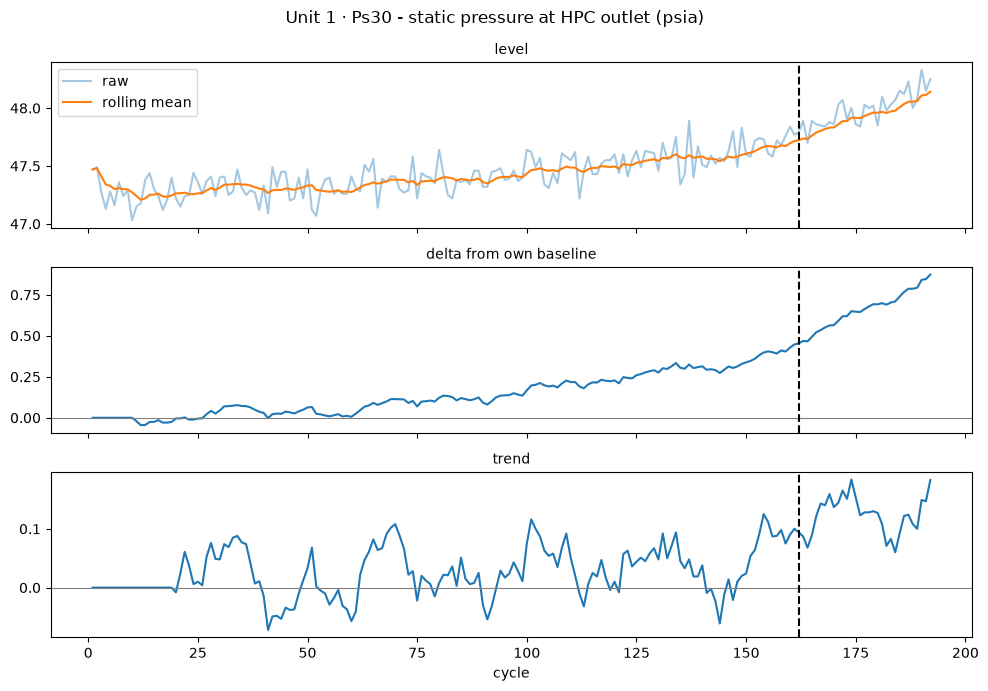

In [2]:
unit_id, sensor = 1, "sensor_11"
in_unit = train["unit"] == unit_id
unit, unit_features = train[in_unit], features[in_unit]
label_start = unit["cycle"].max() - HORIZON

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(unit["cycle"], unit[sensor], alpha=0.4, label="raw")
axes[0].plot(unit["cycle"], unit_features[f"{sensor}_mean{config.window}"], label="rolling mean")
axes[0].legend()
axes[1].plot(unit["cycle"], unit_features[f"{sensor}_delta_baseline"])
axes[1].axhline(0, color="grey", linewidth=0.8)
axes[2].plot(unit["cycle"], unit_features[f"{sensor}_trend{config.trend_lag}"])
axes[2].axhline(0, color="grey", linewidth=0.8)
for ax, title in zip(axes, ["level", "delta from own baseline", "trend"], strict=True):
    ax.axvline(label_start, color="black", linestyle="--")
    ax.set_title(title, fontsize=10)
axes[2].set_xlabel("cycle")
fig.suptitle(f"Unit {unit_id} · {SENSOR_DESCRIPTIONS[sensor]}")
fig.tight_layout()
plt.show()

## 2. Do the features carry more signal than the raw sensors?

Spearman correlation with RUL, sensor by sensor. Smoothing usually increases the correlation simply because it removes noise, not because it adds new information. The question for `delta_baseline` is whether removing each unit's offset helps beyond smoothing.

In [3]:
def spearman_with_rul(column):
    return column.corr(train["rul"], method="spearman")


correlations = pd.DataFrame(
    {
        sensor: {
            "raw": spearman_with_rul(train[sensor]),
            "rolling_mean": spearman_with_rul(features[f"{sensor}_mean{config.window}"]),
            "trend": spearman_with_rul(features[f"{sensor}_trend{config.trend_lag}"]),
            "delta_baseline": spearman_with_rul(features[f"{sensor}_delta_baseline"]),
        }
        for sensor in config.sensors
    }
).T
correlations["name"] = [SENSOR_DESCRIPTIONS[s].split(" - ")[0] for s in correlations.index]
correlations.round(3)

,raw,rolling_mean,trend,delta_baseline,name
sensor_2,-0.629,-0.742,-0.356,-0.799,T24
sensor_3,-0.606,-0.750,-0.319,-0.788,T30
sensor_4,-0.702,-0.753,-0.468,-0.852,T50
sensor_7,0.679,0.731,0.445,0.836,P30
sensor_8,-0.574,-0.600,-0.420,-0.724,Nf
sensor_9,-0.322,-0.327,-0.294,-0.374,Nc
sensor_11,-0.718,-0.749,-0.532,-0.865,Ps30
sensor_12,0.693,0.729,0.485,0.841,phi
sensor_13,-0.573,-0.599,-0.403,-0.743,NRf
sensor_14,-0.202,-0.204,-0.201,-0.214,NRc


## 3. Leakage experiment, repeated with features

In notebook 01, with raw sensors, a random row split and a split by unit gave the same PR-AUC. Rolling features make neighbouring rows share information (overlapping windows), so the risk should now be larger. Same diagnostic model, five folds each.

The features are computed once on the full training set. That is legitimate because each row only uses its own unit's past; what changes between the two experiments is only which rows end up in validation.

The model here is a fixed diagnostic (`n_estimators=100` to keep it fast); the model comparison is block 1.3. This cell takes a few minutes.

In [4]:
y = train[LABEL_COLUMN]
model = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=42)
unit_folds = unit_group_kfold(train, n_splits=5)

fold_summary = pd.DataFrame(
    [
        {"fold": i, "units": train["unit"].iloc[idx].nunique(), "positive_rate": y.iloc[idx].mean()}
        for i, (_, idx) in enumerate(unit_folds, start=1)
    ]
)
print("Validation folds (no stratification needed: every unit has HORIZON + 1 positive cycles)")
print(fold_summary.round(3).to_string(index=False))

splits = {
    "random rows (KFold, shuffled)": KFold(n_splits=5, shuffle=True, random_state=42),
    "whole units (GroupKFold)": unit_folds,
}
leakage = pd.DataFrame(
    {
        name: cross_val_score(model, features, y, cv=cv, scoring="average_precision")
        for name, cv in splits.items()
    }
).T
leakage.columns = [f"fold_{i}" for i in range(1, leakage.shape[1] + 1)]
leakage.assign(mean=leakage.mean(axis=1), std=leakage.std(axis=1)).round(3)

Validation folds (no stratification needed: every unit has HORIZON + 1 positive cycles)
 fold  units  positive_rate
    1     20           0.15
    2     20           0.15
    3     20           0.15
    4     20           0.15
    5     20           0.15


,fold_1,fold_2,fold_3,fold_4,fold_5,mean,std
"random rows (KFold, shuffled)",0.991,0.994,0.994,0.996,0.993,0.994,0.002
whole units (GroupKFold),0.959,0.981,0.974,0.978,0.969,0.972,0.008


## 4. Should the age of the unit (`cycle`) be a feature?

The age of a unit is known at prediction time, so using it is not leakage. The risk is different: in this fleet every unit fails between cycle 128 and 362, so the model could learn "old units fail" instead of reading their health, and that would not transfer to units with a different life.

Decision rule, fixed **before** looking at the result: `cycle` is added only if it improves grouped PR-AUC by more than one standard deviation across folds.

In [14]:
def grouped_pr_auc(feature_matrix):
    scores = cross_val_score(model, feature_matrix, y, cv=unit_folds, scoring="average_precision")
    return pd.Series({"mean": scores.mean(), "std": scores.std()})


with_cycle = build_features(train, FeatureConfig(include_cycle=True))
pd.DataFrame(
    {
        "without cycle": grouped_pr_auc(features),
        "with cycle": grouped_pr_auc(with_cycle),
    }
).T.round(4)

,mean,std
without cycle,0.9724,0.0076
with cycle,0.9812,0.0058


## 5. Findings (block 1.2)

- **Raw vs features:** `delta_baseline` has the strongest correlation with RUL for all 14 sensors (|ρ| up to 0.865 for sensor 11, vs 0.718 raw). Smoothing (raw → rolling mean) adds up to +0.14, mostly for noisy or quantised sensors (3, 17, 2, 20, 21); removing each unit's offset (rolling mean → `delta_baseline`) adds a further +0.03 to +0.14, most for the fan speeds 13 and 8 and for sensors 11, 12 and 7. Sensors 9 and 14 stay far below the rest (−0.37 / −0.21): removing an offset cannot fix trends that go in opposite directions across units. `trend` is the weakest on its own (|ρ| 0.20–0.51): it is noisy and near zero for most of a unit's life, so any value it has is concentrated near failure.
- **Warm-up artefact:** the unit 1 plot shows a spike in `trend` around cycle 11, because early rolling means cover fewer than 10 cycles. Fixed after this run: `trend` is 0 until both windows are complete (cycle ≥ 20), with a dedicated test.
- **Leakage with features:** random rows 0.994 ± 0.001 vs whole units 0.973 ± 0.008. With overlapping windows the gap appears, as anticipated in notebook 01: each validation row has near-identical neighbours in training. The random split hides most of the real errors (1 − PR-AUC of 0.006 vs 0.027, about 4.5 times smaller) and is suspiciously stable. Grouped CV by unit is confirmed. Folds are balanced without stratification (positive rate 0.15 in every fold).
- **Cycle ablation:** 0.973 ± 0.008 without vs 0.981 ± 0.006 with `cycle`. The gain (+0.008) equals one standard deviation, so it does not exceed the pre-registered threshold: `cycle` is not used. A borderline result defaults to the simpler model, and the risk of learning this fleet's lifetimes instead of health remains.
- **Open questions:**
  - Raw sensors vs engineered features under the same protocol (0.961 in notebook 01 used a single split and a different forest, so it is not a fair comparison) → block 1.3.
  - How do validation scores (15% prevalence) translate to the test set (2.5%)? → block 1.3.
  - Does `trend` add value beyond `delta_baseline`, and how do the redundant pairs (8/13, 9/14) split attributions? → block 1.5.

## 6. Model comparison (block 1.3)

Every candidate is a complete Pipeline (raw sensor history → features → model) evaluated with the **same five unit folds** as section 3, so the comparison is fair and no row is ever scored by a model that saw its unit.

- **Candidates**, from simplest to most complex: logistic regression, random forest, gradient boosting (scikit-learn's histogram implementation) and XGBoost.
- **Reference:** a random forest on the raw sensors of the current cycle. It answers the open question of block 1.2: do the engineered features help under the same protocol?
- **Hyperparameters:** fixed, reasonable defaults, not tuned. With 100 units, tuning on the same folds used to compare models would make the comparison optimistic (see D-020).
- **Primary metric: PR-AUC.** Accuracy is misleading with 15% positives: a model that never predicts failure is already 85% accurate. PR-AUC focuses on the positive class; its value for a random model equals the prevalence (0.15).

This cell trains 25 models and takes a few minutes.

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve

from industrial_ai.evaluation.metrics import (
    first_alarms,
    last_cycle_mask,
    select_threshold,
    threshold_metrics,
)
from industrial_ai.ml.data import load_rul
from industrial_ai.ml.labels import add_rul_test
from industrial_ai.ml.models import MODEL_NAMES, build_pipeline, model_inputs
from industrial_ai.ml.selection import cross_validate_by_unit, simplest_within_one_std

X = model_inputs(train)  # unit, cycle and sensors only: the labels never enter the model
print(f"Accuracy of a model that never predicts failure: {1 - y.mean():.3f}")

candidates = {"random_forest · raw sensors (reference)": build_pipeline("random_forest", "raw")}
candidates |= {name: build_pipeline(name) for name in MODEL_NAMES}

cv_results = {}
for label, pipeline in candidates.items():
    cv_results[label] = cross_validate_by_unit(pipeline, X, y, unit_folds)
    print(f"done: {label}")

comparison = pd.DataFrame({label: result.summary() for label, result in cv_results.items()}).T
comparison.round(3)

Accuracy of a model that never predicts failure: 0.850
done: random_forest · raw sensors (reference)
done: logistic_regression
done: random_forest
done: hist_gradient_boosting
done: xgboost


,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,fit_seconds
random_forest · raw sensors (reference),0.951,0.008,0.989,0.002,7.652
logistic_regression,0.973,0.005,0.995,0.001,0.931
random_forest,0.972,0.008,0.995,0.001,10.857
hist_gradient_boosting,0.976,0.010,0.995,0.002,5.998
xgboost,0.976,0.009,0.996,0.002,5.804


## 7. Model selection

Rule fixed **before** looking at the results: choose the **simplest candidate whose mean PR-AUC is within one standard deviation of the best** (the best candidate's own standard deviation across folds). A difference smaller than the fold-to-fold noise is not evidence for a more complex model. Complexity order: logistic regression < random forest < gradient boosting < XGBoost (fewer knobs and more transparent behaviour first). The raw-sensor reference is not a candidate.

The plot shows each model's PR-AUC per fold. If the lines move together, the hard part is *which units* are in the fold, not which model is used.

Selected model: logistic_regression


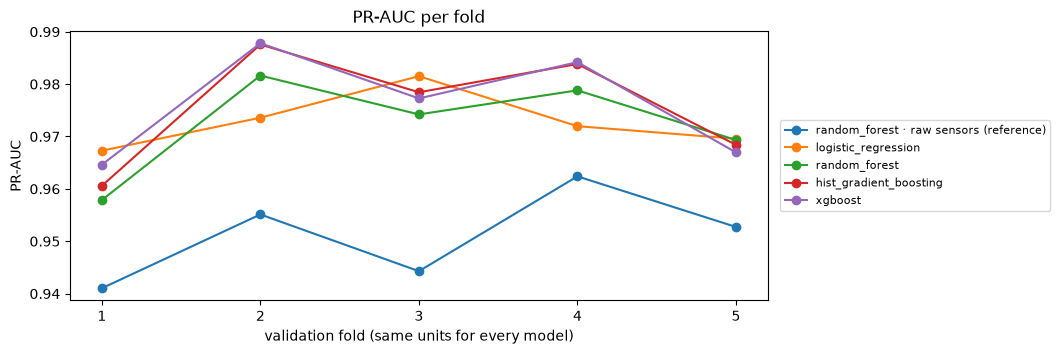

In [7]:
selected = simplest_within_one_std(comparison.loc[list(MODEL_NAMES)], MODEL_NAMES)
print(f"Selected model: {selected}")

fold_scores = pd.DataFrame({label: result.fold_pr_auc for label, result in cv_results.items()})
fig, ax = plt.subplots(figsize=(9, 3.5))
for label in fold_scores:
    ax.plot(range(1, len(unit_folds) + 1), fold_scores[label], marker="o", label=label)
ax.set(
    xlabel="validation fold (same units for every model)",
    ylabel="PR-AUC",
    title="PR-AUC per fold",
    xticks=range(1, len(unit_folds) + 1),
)
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.show()

## 8. Decision threshold

A model outputs a risk score; an **alarm** needs a threshold. 0.5 is an arbitrary default.

Rule fixed before looking at the results: the threshold with the **highest precision among those that reach recall ≥ 0.90**, chosen on the **out-of-fold** scores of the selected model (never on training predictions, never on the test set).

Why recall first: in this scenario, missing the warning window before a failure is assumed to cost more than an unnecessary inspection. That is a business assumption, not a universal truth: too many false alarms cause *alarm fatigue* and operators start ignoring them. With real maintenance costs, the threshold would minimise expected cost instead.

In [8]:
MIN_RECALL = 0.90
oof_scores = cv_results[selected].oof_scores
threshold = select_threshold(y, oof_scores, MIN_RECALL)

shown = ["threshold", "precision", "recall", "f1", "false_positive_rate", "false_negative_rate"]
shown += ["accuracy", "tp", "fp", "fn", "tn"]
pd.DataFrame(
    {
        "default threshold 0.5": threshold_metrics(y, oof_scores, 0.5),
        "selected threshold": threshold_metrics(y, oof_scores, threshold),
    }
).T[shown].round(3)

,threshold,precision,recall,f1,false_positive_rate,false_negative_rate,accuracy,tp,fp,fn,tn
default threshold 0.5,0.500,0.898,0.898,0.898,0.018,0.102,0.969,2783.0,315.0,317.0,17216.0
selected threshold,0.483,0.897,0.900,0.898,0.018,0.100,0.969,2790.0,322.0,310.0,17209.0


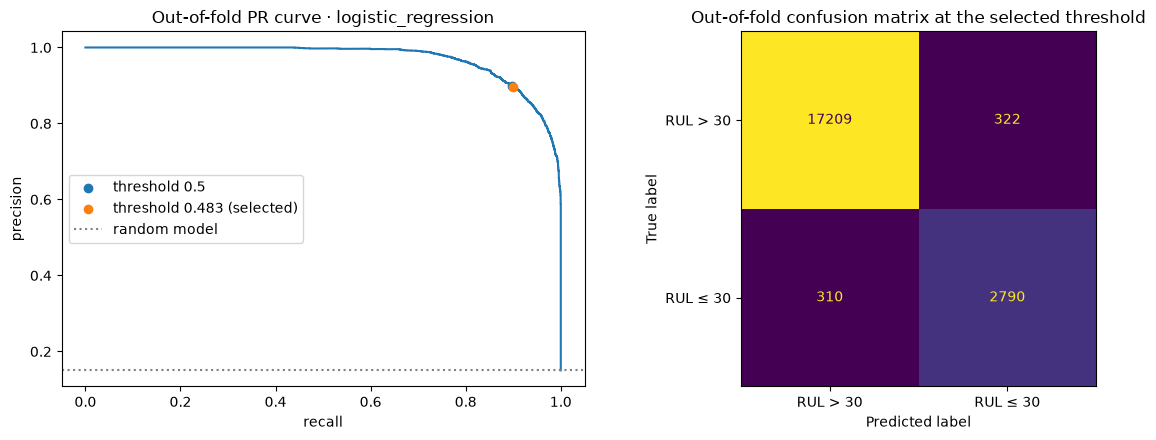

In [9]:
precision, recall, _ = precision_recall_curve(y, oof_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(recall, precision)
for name, value in [("0.5", 0.5), (f"{threshold:.3f} (selected)", threshold)]:
    point = threshold_metrics(y, oof_scores, value)
    axes[0].scatter(point["recall"], point["precision"], zorder=3, label=f"threshold {name}")
axes[0].axhline(y.mean(), color="grey", linestyle=":", label="random model")
axes[0].set(xlabel="recall", ylabel="precision", title=f"Out-of-fold PR curve · {selected}")
axes[0].legend()
ConfusionMatrixDisplay.from_predictions(
    y,
    (oof_scores >= threshold).astype(int),
    display_labels=[f"RUL > {HORIZON}", f"RUL ≤ {HORIZON}"],
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Out-of-fold confusion matrix at the selected threshold")
fig.tight_layout()
plt.show()

## 9. When does each unit raise its first alarm?

Row metrics count every cycle separately, but maintenance reacts to the **first alarm** of a unit. On out-of-fold scores every training unit fails, so we can measure how much warning each one would have given (its RUL at the first alarm):

- **missed:** no alarm before failure;
- **in window:** first alarm within the last `HORIZON` cycles;
- **early:** between `HORIZON` and `2 × HORIZON` cycles before failure, still useful warning;
- **premature:** more than `2 × HORIZON` cycles before failure, probably a false alarm.

Requiring the score to stay above the threshold for 3 consecutive cycles filters isolated spikes, at the cost of a few cycles of delay.

In [10]:
def alarm_outcomes(consecutive):
    rul = first_alarms(train, oof_scores, threshold, consecutive)["rul_at_first_alarm"]
    return pd.Series(
        {
            "missed (no alarm)": rul.isna().sum(),
            f"in window (RUL ≤ {HORIZON})": (rul <= HORIZON).sum(),
            f"early ({HORIZON} < RUL ≤ {2 * HORIZON})": rul.between(HORIZON + 1, 2 * HORIZON).sum(),
            f"premature (RUL > {2 * HORIZON})": (rul > 2 * HORIZON).sum(),
            "median RUL at first alarm": rul.median(),
            "least warning (min RUL at first alarm)": rul.min(),
            "unit with least warning": rul.idxmin(),
        }
    )


pd.DataFrame({f"{k} consecutive cycle(s)": alarm_outcomes(k) for k in (1, 3)})

,1 consecutive cycle(s),3 consecutive cycle(s)
missed (no alarm),0.0,0.0
in window (RUL ≤ 30),48.0,66.0
early (30 < RUL ≤ 60),51.0,33.0
premature (RUL > 60),1.0,1.0
median RUL at first alarm,31.0,27.0
least warning (min RUL at first alarm),16.0,14.0
unit with least warning,57.0,57.0


## 10. Final evaluation on the test set

The selected pipeline is refitted on all 100 training units and evaluated **once** on the test set, with the threshold chosen in section 8. Two views:

- **every cycle:** continuous monitoring of the fleet;
- **last cycle per unit:** the usual benchmark protocol, one prediction per unit.

Expected effect of the prevalence shift (15% → 2.5% positive cycles): recall should be comparable with cross-validation, while precision and PR-AUC will be lower, simply because there are fewer positives to find. The PR-AUC of a random model equals the prevalence of each view.

In [11]:
test = add_rul_test(load_trajectories("FD001", "test"), load_rul("FD001"))
test = add_failure_label(test, HORIZON)
final_model = build_pipeline(selected).fit(X, y)
test_scores = final_model.predict_proba(model_inputs(test))[:, 1]
last = last_cycle_mask(test).to_numpy()
y_test = test[LABEL_COLUMN].to_numpy()

shown = ["prevalence", "pr_auc", "roc_auc", "precision", "recall", "f1"]
shown += ["false_positive_rate", "tp", "fp", "fn", "tn"]
pd.DataFrame(
    {
        "cross-validation (out-of-fold)": threshold_metrics(y, oof_scores, threshold),
        "test · every cycle": threshold_metrics(y_test, test_scores, threshold),
        "test · last cycle per unit": threshold_metrics(y_test[last], test_scores[last], threshold),
    }
).T[shown].round(3)

,prevalence,pr_auc,roc_auc,precision,recall,f1,false_positive_rate,tp,fp,fn,tn
cross-validation (out-of-fold),0.150,0.972,0.995,0.897,0.900,0.898,0.018,2790.0,322.0,310.0,17209.0
test · every cycle,0.025,0.890,0.996,0.817,0.753,0.784,0.004,250.0,56.0,82.0,12708.0
test · last cycle per unit,0.250,0.973,0.992,0.913,0.840,0.875,0.027,21.0,2.0,4.0,73.0


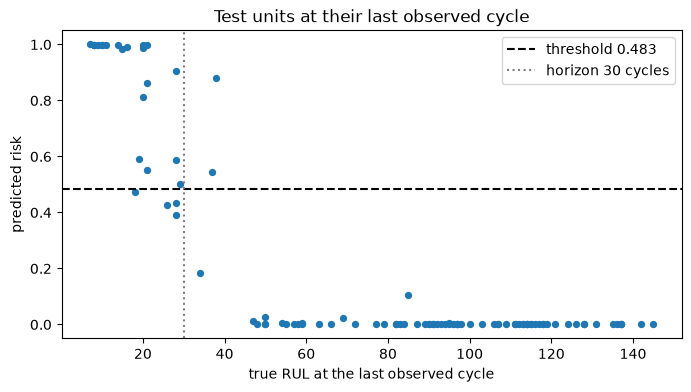

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(test["rul"].to_numpy()[last], test_scores[last], s=18)
ax.axhline(threshold, color="black", linestyle="--", label=f"threshold {threshold:.3f}")
ax.axvline(HORIZON, color="grey", linestyle=":", label=f"horizon {HORIZON} cycles")
ax.set(
    xlabel="true RUL at the last observed cycle",
    ylabel="predicted risk",
    title="Test units at their last observed cycle",
)
ax.legend()
plt.show()

### Recall by distance to failure

Recall drops from cross-validation to test. Hypothesis: test positives are concentrated near the horizon (truncated units contribute few positive cycles, mostly close to RUL 30), where the classes are hardest to separate. If it holds, recall within each band should be similar in cross-validation and test; only the mix of bands should differ.

In [13]:
def recall_by_rul_band(frame, scores):
    positives = (frame[LABEL_COLUMN] == 1).to_numpy()
    band = pd.cut(
        frame["rul"].to_numpy()[positives],
        bins=[-1, 10, 20, HORIZON],
        labels=["RUL 0–10", "RUL 11–20", f"RUL 21–{HORIZON}"],
    )
    detected = pd.Series(scores[positives] >= threshold)
    summary = detected.groupby(band, observed=False).agg(["size", "mean"])
    return summary.rename(columns={"size": "positive cycles", "mean": "recall"})


pd.concat(
    {
        "cross-validation": recall_by_rul_band(train, oof_scores),
        "test · every cycle": recall_by_rul_band(test, test_scores),
    },
    axis=1,
).round(3)

cross-validation        test · every cycle       
           positive cycles recall    positive cycles recall
RUL 0–10              1100  1.000                 17  1.000
RUL 11–20             1000  0.989                106  0.991
RUL 21–30             1000  0.701                209  0.612

## 11. Findings (block 1.3)

- **Accuracy trap:**
- **Model comparison:** PR-AUC (mean ± std) of each candidate, and raw sensors vs engineered features:
- **Selection:** result of the rule and why:
- **Fold variability:** do models move together across folds?
- **Threshold:** value, out-of-fold precision and recall, and comparison with 0.5:
- **Alarms per unit:** missed / in window / early / premature, and the effect of 3 consecutive cycles:
- **Test set:** every cycle vs last cycle, and the effect of the prevalence shift:
- **Where the errors are:** what the last-cycle scatter shows about errors near the horizon:
- **Open questions:**